# Redundancia entre nodos en OptimusKG: `Disease`, `Phenotype` y `Drug`

Las capas del grafo mezclan varias ontologías. La de enfermedades tiene identificadores MONDO, EFO,
Orphanet, DOID y OTAR conviviendo; la de fenotipos tiene HP y MedDRA; la de drogas tiene ChEMBL,
DrugBank y RxNorm. La pregunta de este notebook es si esa convivencia deja el mismo concepto cargado
más de una vez.

La respuesta corta es que sí, y por un mecanismo que está en cómo se construyó el grafo. OptimusKG
agrupa sus fuentes por prefijo CURIE y, según su paper, deduplica los registros que comparten nombre
con distinto identificador dentro de Open Targets. Lo que no hace es cruzar identificadores entre
fuentes: cuando una fuente secundaria (CTD, OnSIDES, DrugBank) referencia una entidad con un
identificador de otro espacio, entra un nodo nuevo con las aristas de esa fuente y nada más. El
mismo problema está reportado río arriba en Open Targets, donde una enfermedad aparece a la vez como
término MONDO y como término HP con evidencia que no se solapa.

Al medirlo aparecieron **dos fenómenos distintos que conviene no mezclar**. Uno es la redundancia de
identidad: dos nodos que son la misma entidad. El otro es la indistinguibilidad topológica: dos
nodos que son entidades diferentes pero tienen exactamente las mismas conexiones, y por lo tanto
ningún algoritmo que mire solo la estructura del grafo puede separarlos. Los dos importan para el
pipeline, pero por razones distintas y con consecuencias distintas.

Acá se mide. Qué hacer con lo que aparezca (marcar un identificador canónico, fusionar nodos, o
dejarlo documentado y seguir) es una decisión posterior. Este notebook no escribe nada en Neo4j.

Requiere Neo4j corriendo con OptimusKG cargado y la propiedad `is_truly_disease` ya aplicada por
`marcar_enfermedades_reales.py`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from neo4j import GraphDatabase

sys.path.insert(0, "../loader")
from config import NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD

from redundancia import (elegir_representante, es_cascara, grupos_de_equivalencia, grupos_por_clave,
                         hash_vecindario, jaccard, normalizar, pares_de_grupos, pares_desde_sssom,
                         pares_por_referencia, pares_por_sinonimo, unir_declarados, unir_senales)

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()

def consultar(cypher, **parametros):
    """Corre una consulta de lectura y devuelve el resultado como DataFrame."""
    with driver.session() as sesion:
        return pd.DataFrame([dict(fila) for fila in sesion.run(cypher, **parametros)])

In [2]:
#cada capa aporta las mismas señales pero con nombres de propiedad distintos, asi que lo unico que
#cambia entre las tres es esta tabla. la capa Disease se restringe a las enfermedades reales porque
#el resto son rasgos y mediciones, ver limpieza_capa_disease.ipynb
CAPAS = {
    "Disease": {
        "filtro": "n.is_truly_disease",
        "jerarquia": "PARENT",
        "sinonimos": ["exact_synonyms"],
        "referencias": ["xrefs", "obsolete_xrefs"],
        "externos": ["umls_cui"],
        "cosecha": ["ASSOCIATED_WITH", "INDICATION", "PHENOTYPE_PRESENT"],
    },
    "Phenotype": {
        "filtro": "true",
        "jerarquia": "PARENT",
        "sinonimos": ["exact_synonyms"],
        "referencias": ["xrefs", "obsolete_xrefs"],
        "externos": ["umls_cui"],
        "cosecha": ["ASSOCIATED_WITH", "PHENOTYPE_PRESENT", "INDICATION"],
    },
    "Drug": {
        "filtro": "true",
        "jerarquia": "PARENT",
        "sinonimos": ["synonyms", "trade_names"],
        "referencias": ["source_ids", "accession_numbers"],
        #inchi_key identifica la molecula: dos drogas que lo comparten son la misma sustancia
        "externos": ["inchi_key", "chemical_abstracts_service_number", "unique_ingredient_identifier"],
        "cosecha": ["TARGET", "INDICATION"],
    },
}

COLORES = {"identidad": "#2a78d6", "topologica": "#eb6834", "jerarquia": "#eda100", "otro": "#1baf7a"}
SUPERFICIE, TINTA, TINTA_SUAVE = "#fcfcfb", "#0b0b0b", "#52514e"

def preparar(ax, titulo, xlabel=None):
    """Ejes con grilla tenue detras de las barras y sin marco a la derecha ni arriba."""
    ax.set_title(titulo, color=TINTA, fontsize=12, pad=12, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel, color=TINTA_SUAVE, fontsize=9)
    ax.grid(axis="x", color="#e5e5e2", linewidth=0.6)
    ax.set_axisbelow(True)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color("#d8d8d4")
    ax.tick_params(colors=TINTA_SUAVE, labelsize=9, length=0)

## Cómo se detecta

Cada señal produce pares de identificadores. Ninguna alcanza sola: la tabla final las cruza, y un par
marcado por dos señales independientes es mucho más creíble que uno marcado por una sola.

Las cuatro primeras apuntan a **identidad**, o sea a que los dos nodos son la misma entidad.

| Señal | Qué compara | Por qué es evidencia |
|---|---|---|
| `nombre` | El nombre, normalizado: sin tildes, sin puntuación, sin apóstrofes, y sin el sufijo final que dos ontologías intercambian (`disease`, `disorder`, `syndrome`) | Dos ontologías que describen el mismo concepto suelen coincidir en cómo lo nombran |
| `sinonimo` | Un sinónimo exacto de un nodo contra el nombre de otro | Es la relación de equivalencia que la propia ontología declara, con otro nombre |
| `referencia` | Las referencias cruzadas de un nodo apuntando a un identificador que existe como nodo de la misma capa | Es el nodo diciendo explícitamente que el otro es él mismo |
| `externo` | Un identificador de un vocabulario externo compartido: `umls_cui` en enfermedades y fenotipos, `inchi_key` en drogas | Dos nodos con el mismo InChIKey son la misma molécula |

Las tres últimas miran la **estructura**, y responden algo distinto: si el grafo permite distinguir
un nodo del otro.

| Señal | Qué compara | Qué significa |
|---|---|---|
| `vecindario` | El conjunto completo de pares (tipo de relación, vecino), resumido en un hash | Dos nodos con el mismo vecindario son intercambiables para cualquier algoritmo topológico |
| `jaccard` | Solapamiento de vecindarios, solo sobre pares que ya salieron por otra señal | Gradúa cuánto se parecen los que no son idénticos |

Queda una octava medición que no produce pares y por eso no es una señal: si un nodo es una
**cáscara**, o sea si no participa de la jerarquía de su capa y toda su vecindad viene de un solo
tipo de relación. Es el perfil del nodo que aporta una fuente secundaria, y entra a la tabla como una
columna del par, no como evidencia de que dos nodos sean el mismo.

Una nota de método sobre el vecindario. Compararlo entre todos los pares de una capa es inviable
(la capa `Disease` tiene diez millones de aristas), pero no hace falta: dos nodos con el mismo
vecindario tienen, necesariamente, el mismo grado en cada tipo de relación. Esa firma de grado se
calcula agregando en Neo4j, sale barata, y **solo se traen los vecindarios reales de los nodos cuya
firma está repetida**. El resultado es exacto, no aproximado, porque la firma es condición necesaria.

Sobre esos grupos hay que hacer un recorte más, que no estaba previsto y salió de mirar el resultado.
La enorme mayoría son grupos de grado uno: hojas que cuelgan de un mismo padre único y no tienen
ninguna otra arista. Son miles, no dicen nada sobre identidad, y ningún algoritmo de expansión llega
a elegirlos. La señal se queda con los grupos de grado dos o más y la distribución completa se
reporta aparte.

In [3]:
def senales_de_la_capa(capa):
    """Corre las siete señales sobre una capa y devuelve las piezas intermedias junto con la tabla cruzada. Se hace en una sola funcion porque las tres capas comparten el procedimiento entero y solo cambian los nombres de propiedad de CAPAS."""
    configuracion = CAPAS[capa]
    filtro = configuracion["filtro"]
    propiedades = configuracion["sinonimos"] + configuracion["referencias"] + configuracion["externos"]
    devuelve = ", ".join(f"n.{propiedad} AS {propiedad}" for propiedad in propiedades)

    nodos = consultar(f"""
        MATCH (n:{capa}) WHERE {filtro}
        RETURN n.id AS id, n.name AS nombre, n.sources_json AS fuentes,
               split(n.id, CASE WHEN n.id CONTAINS ':' THEN ':' ELSE '_' END)[0] AS espacio,
               COUNT {{ (n)-[:{configuracion["jerarquia"]}]-() }} AS jerarquia,
               COUNT {{ (n)--() }} AS grado,
               {devuelve}""")

    senales = {}
    #1. nombre normalizado
    grupos_nombre = grupos_por_clave(nodos, "nombre", normalizador=normalizar)
    senales["nombre"] = pares_de_grupos(grupos_nombre)

    #2. sinonimo exacto de uno igual al nombre de otro
    nombres = dict(zip(nodos["id"], nodos["nombre"]))
    pares_sinonimo = []
    for propiedad in configuracion["sinonimos"]:
        sinonimos = {f["id"]: f[propiedad] for f in nodos.to_dict("records") if f[propiedad] is not None}
        pares_sinonimo += pares_por_sinonimo(nombres, sinonimos)
    senales["sinonimo"] = sorted(set(pares_sinonimo))

    #3. referencia cruzada que apunta a un nodo de la misma capa
    pares_referencia = []
    for propiedad in configuracion["referencias"]:
        referencias = {f["id"]: f[propiedad] for f in nodos.to_dict("records") if f[propiedad] is not None}
        pares_referencia += pares_por_referencia(referencias, list(nodos["id"]))
    senales["referencia"] = sorted(set(pares_referencia))

    #4. identificador externo compartido
    pares_externo = []
    for propiedad in configuracion["externos"]:
        pares_externo += pares_de_grupos(grupos_por_clave(nodos, propiedad))
    senales["externo"] = sorted(set(pares_externo))

    #5. vecindario identico. la firma de grado es condicion necesaria, asi que se usa para no traer
    #las diez millones de aristas de la capa y quedarse solo con los candidatos posibles
    firmas = consultar(f"""
        MATCH (n:{capa})-[r]-(o) WHERE {filtro}
        WITH n.id AS id, type(r) AS rel, count(*) AS c
        RETURN id, collect(rel + '=' + toString(c)) AS partes""")
    firmas["firma"] = firmas["partes"].apply(lambda partes: ",".join(sorted(partes)))
    candidatos = sorted({i for ids in grupos_por_clave(firmas, "firma").values() for i in ids})
    vecindarios = consultar(f"""
        MATCH (n:{capa})-[r]-(o) WHERE n.id IN $ids
        RETURN n.id AS id, collect(DISTINCT type(r) + ':' + o.id) AS vecinos""", ids=candidatos)
    vecindarios["hash"] = vecindarios["vecinos"].apply(hash_vecindario)
    vecindarios["grado_distinto"] = vecindarios["vecinos"].apply(len)
    grupos_vecindario = grupos_por_clave(vecindarios, "hash")
    #un grupo de grado 1 son hojas que cuelgan del mismo unico padre: hay miles, no dicen nada
    #sobre identidad y ningun algoritmo de expansion los llega a elegir. la señal se queda con los
    #grupos de grado 2 o mas, y la distribucion completa se reporta aparte
    grado_distinto = dict(zip(vecindarios["id"], vecindarios["grado_distinto"]))
    con_grado = {clave: ids for clave, ids in grupos_vecindario.items()
                 if grado_distinto[ids[0]] >= 2}
    senales["vecindario"] = pares_de_grupos(con_grado)

    #6. jaccard, solo sobre los pares que ya salieron por una señal de identidad, porque calcularlo
    #entre todos los pares de la capa es cuadratico y no aporta
    de_identidad = {(a, b) for clave in ("nombre", "sinonimo", "referencia", "externo")
                    for a, b, _ in senales[clave]}
    involucrados = sorted({i for par in de_identidad for i in par})
    vecinos_por_id = {}
    if involucrados:
        traidos = consultar(f"""
            MATCH (n:{capa})-[r]-(o) WHERE n.id IN $ids
            RETURN n.id AS id, collect(DISTINCT type(r) + ':' + o.id) AS vecinos""", ids=involucrados)
        vecinos_por_id = dict(zip(traidos["id"], traidos["vecinos"]))
    similitud = {par: jaccard(vecinos_por_id.get(par[0], []), vecinos_por_id.get(par[1], []))
                 for par in de_identidad}
    senales["jaccard"] = [(a, b, round(valor, 3)) for (a, b), valor in similitud.items() if valor >= 0.9]

    #7. cascaras: sin jerarquia y con un solo tipo de relacion. no es una señal de pares sino una
    #propiedad de un nodo, asi que entra a la tabla como columna y no como columna booleana de señal
    tipos = consultar(f"""
        MATCH (n:{capa})-[r]-() WHERE {filtro}
        RETURN n.id AS id, collect(DISTINCT type(r)) AS tipos""")
    tipos_por_id = dict(zip(tipos["id"], tipos["tipos"]))
    jerarquia_por_id = dict(zip(nodos["id"], nodos["jerarquia"]))
    cascaras = {i for i in nodos["id"]
                if es_cascara(jerarquia_por_id.get(i, 0), tipos_por_id.get(i, []))}

    tabla = unir_senales(senales)
    grado_por_id = dict(zip(nodos["id"], nodos["grado"]))
    if len(tabla):
        tabla.insert(2, "grado_a", tabla["id_a"].map(grado_por_id))
        tabla.insert(3, "grado_b", tabla["id_b"].map(grado_por_id))
        tabla.insert(2, "nombre_a", tabla["id_a"].map(nombres))
        tabla.insert(3, "nombre_b", tabla["id_b"].map(nombres))
        tabla["alguno_es_cascara"] = tabla["id_a"].isin(cascaras) | tabla["id_b"].isin(cascaras)
        #de identidad son las cuatro primeras señales, el vecindario responde otra pregunta
        tabla["de_identidad"] = tabla[["nombre", "sinonimo", "referencia", "externo"]].any(axis=1)
    return {"capa": capa, "nodos": nodos, "senales": senales, "tabla": tabla,
            "grupos_nombre": grupos_nombre, "grupos_vecindario": grupos_vecindario,
            "vecindarios": vecindarios, "similitud": similitud, "cascaras": cascaras}

## La capa `Disease`

Se trabaja sobre las 17.308 enfermedades reales, las que `marcar_enfermedades_reales.py` dejó
marcadas con `is_truly_disease`. Los rasgos y mediciones que ocupan el resto de la capa quedan
afuera porque el algoritmo tampoco los usa.

In [4]:
disease = senales_de_la_capa("Disease")
nodos_disease = disease["nodos"]

print(f"{len(nodos_disease):,} enfermedades reales")
print("\nespacios de identificador:")
print(nodos_disease["espacio"].value_counts().to_string())
print("\npropiedades de identidad disponibles:")
for propiedad in ["exact_synonyms", "xrefs", "obsolete_xrefs", "umls_cui"]:
    print(f"  {propiedad:18s} {nodos_disease[propiedad].notna().sum():6,} nodos")

17,308 enfermedades reales

espacios de identificador:
espacio
MONDO       11685
EFO          3927
Orphanet     1635
OBA            40
OTAR            9
DOID            6
NCIT            3
OBI             2
OGMS            1

propiedades de identidad disponibles:
  exact_synonyms     10,144 nodos
  xrefs               8,661 nodos
  obsolete_xrefs     17,086 nodos
  umls_cui            1,067 nodos


In [5]:
resumen_senales = pd.DataFrame([
    {"señal": nombre, "pares": len(pares),
     "nodos": len({i for a, b, _ in pares for i in (a, b)})}
    for nombre, pares in disease["senales"].items()])
resumen_senales

,señal,pares,nodos
0,nombre,586,1163
1,sinonimo,1977,3073
2,referencia,1069,2129
3,externo,23,43
4,vecindario,153,181
5,jaccard,194,385


El caso que motivó todo esto sirve de testigo: `hepatocellular carcinoma` existe dos veces en la
capa, con dos identificadores de ontologías distintas y con vecindarios que no se tocan.

In [6]:
consultar("""
    MATCH (d:Disease) WHERE d.is_truly_disease AND toLower(d.name) = 'hepatocellular carcinoma'
    RETURN d.id AS id, d.name AS nombre, COUNT { (d)--() } AS grado,
           size(coalesce(d.ancestors, [])) AS ancestros, d.umls_cui AS umls, d.sources_json AS fuentes""")

,id,nombre,grado,ancestros,umls,fuentes
0,EFO_0000182,hepatocellular carcinoma,13889,21,C2239176,"{""direct"": [""OPEN_TARGETS"", ""DRUG_CENTRAL"", ""M..."
1,MONDO_0007256,hepatocellular carcinoma,2,0,None,"{""direct"": [""OPEN_TARGETS"", ""DRUG_CENTRAL"", ""M..."


Los dos nodos declaran la misma procedencia y ninguno es más específico que el otro: el segundo
simplemente no tiene jerarquía ni evidencia. Ese patrón se repite, y los pares marcados por más
señales son los más creíbles.

In [7]:
#los pares marcados por mas señales son los mas creibles, y la tabla ya viene ordenada asi
columnas = ["id_a", "nombre_a", "grado_a", "id_b", "grado_b", "n_senales",
            "nombre", "sinonimo", "referencia", "externo", "vecindario"]
disease["tabla"][columnas].head(12)

,id_a,nombre_a,grado_a,id_b,grado_b,n_senales,nombre,sinonimo,referencia,externo,vecindario
0,EFO_0009086,arteriosclerosis,6220,MONDO_0002277,6193,4,True,True,False,True,False
1,MONDO_0007120,aniridia-absent patella syndrome,149,Orphanet_1069,140,4,True,True,True,False,False
2,MONDO_0007225,fibular aplasia-ectrodactyly syndrome,174,Orphanet_1118,158,4,True,True,True,False,False
3,MONDO_0007226,brachydactyly-nystagmus-cerebellar ataxia synd...,26,Orphanet_1246,25,4,True,True,True,False,False
4,MONDO_0007438,dentin dysplasia-sclerotic bones syndrome,193,Orphanet_99792,192,4,True,True,True,False,False
5,MONDO_0008158,dacryocystitis-osteopoikilosis syndrome,141,Orphanet_1562,140,4,True,True,True,False,False
6,MONDO_0008245,piebald trait-neurologic defects syndrome,178,Orphanet_2885,167,4,True,True,True,False,False
7,MONDO_0008402,cleft palate-large ears-small head syndrome,41,Orphanet_2013,38,4,True,True,True,False,False
8,MONDO_0008488,holoprosencephaly-radial heart renal anomalies...,61,Orphanet_3186,55,4,True,True,True,False,False
9,MONDO_0008607,triphalangeal thumbs-brachyectrodactyly syndrome,41,Orphanet_2947,40,4,True,True,True,False,False


### El filtro de enfermedades reales no los saca, los concentra

Todo lo de arriba se midió sobre las enfermedades que sobreviven a `is_truly_disease`, así que la
redundancia que aparece ya pasó por esa limpieza. Vale preguntarse qué habría pasado sin ella, y la
respuesta es que el filtro **sube** la proporción de nodos duplicados en vez de bajarla.

Tiene sentido visto de cerca. Los rasgos y mediciones que la limpieza descarta vienen casi todos de
un solo lugar, los estudios de asociación genómica indexados por EFO y OBA, así que no hay dos
ontologías compitiendo por nombrarlos. Las enfermedades reales sí: MONDO, Orphanet, EFO y DOID las
nombran todas, y ahí es donde se duplican.

In [8]:
capa_entera = consultar("""
    MATCH (n:Disease)
    RETURN n.id AS id, n.name AS nombre, n.is_truly_disease AS real, COUNT { (n)--() } AS grado""")

for etiqueta, subconjunto in [("capa completa", capa_entera),
                              ("solo is_truly_disease", capa_entera[capa_entera["real"]]),
                              ("solo las descartadas", capa_entera[~capa_entera["real"]])]:
    pares = pares_de_grupos(grupos_por_clave(subconjunto, "nombre", normalizador=normalizar))
    involucrados = {i for a, b, _ in pares for i in (a, b)}
    print(f"{etiqueta:24s} {len(subconjunto):6,} nodos, {len(pares):4,} pares, "
          f"{len(involucrados):5,} nodos duplicados ({100 * len(involucrados) / len(subconjunto):.1f}%)")

capa completa            36,345 nodos,  646 pares, 1,280 nodos duplicados (3.5%)
solo is_truly_disease    17,308 nodos,  586 pares, 1,163 nodos duplicados (6.7%)


solo las descartadas     19,037 nodos,   51 pares,   102 nodos duplicados (0.5%)


Hay un caso que el filtro deja peor de lo que estaba, y son pocos como para revisarlos a mano. En
nueve pares los dos nodos quedaron de lados distintos de la limpieza, y en cuatro de ellos **la copia
que sobrevivió es la vacía**: el nodo MONDO se quedó con dos o tres aristas hacia exposiciones,
mientras que el nodo EFO, que tenía los cientos de genes, quedó descartado por colgar de la rama
`phenotype` de la ontología.

El criterio de la limpieza hizo exactamente lo que dice hacer, porque esos nodos EFO efectivamente
cuelgan de esa rama. Lo que no estaba previsto es qué pasa cuando una enfermedad existe en dos ramas
a la vez: la consulta que filtra por `is_truly_disease` se queda con la copia sin evidencia y no
tiene forma de enterarse.

In [9]:
real_por_id = dict(zip(capa_entera["id"], capa_entera["real"]))
grado_por_nodo = dict(zip(capa_entera["id"], capa_entera["grado"]))
nombre_por_nodo = dict(zip(capa_entera["id"], capa_entera["nombre"]))

cruzan = [(a, b) for a, b, _ in pares_de_grupos(grupos_por_clave(capa_entera, "nombre", normalizador=normalizar))
          if real_por_id[a] != real_por_id[b]]
frontera = pd.DataFrame([
    {"nombre": nombre_por_nodo[a], "conservado": a if real_por_id[a] else b,
     "grado_conservado": grado_por_nodo[a if real_por_id[a] else b],
     "descartado": b if real_por_id[a] else a,
     "grado_descartado": grado_por_nodo[b if real_por_id[a] else a]}
    for a, b in cruzan]).sort_values("grado_conservado")
print(frontera.to_string(index=False))

                           nombre    conservado  grado_conservado    descartado  grado_descartado
                        cleft lip MONDO_0004747                 2   EFO_0003959               495
 methylmalonic aciduria cblb type   EFO_0009074                 2 MONDO_0009614                58
             vitamin D deficiency MONDO_0100471                 3   EFO_0003762               787
                 essential tremor MONDO_0003233                 3   EFO_0003108               566
                          anxiety MONDO_0005618                 8   EFO_0005230              4466
               vitamin deficiency MONDO_0024298              2149   EFO_0005878              1438
       skin pigmentation disorder MONDO_0019288              2378 OBA_VT0002095                11
                          anxiety   EFO_0006788              3274   EFO_0005230              4466
non-alcoholic fatty liver disease   EFO_0003095              5667   EFO_1001248               850


### De dónde sale cada familia de duplicados

Los pares no son todos del mismo origen. Separarlos por qué señal los marcó y qué forma tiene el nodo
de menor grado de cada par muestra que el problema es más grande que un puñado de nodos vacíos.

In [10]:
tabla_disease = disease["tabla"]
sin_jerarquia = dict(zip(nodos_disease["id"], nodos_disease["jerarquia"]))
fuentes = dict(zip(nodos_disease["id"], nodos_disease["fuentes"]))

#el nodo secundario de un par es el de menor grado: es el que la fuente secundaria trajo
tabla_disease["secundario"] = tabla_disease.apply(
    lambda f: f["id_b"] if f["grado_b"] <= f["grado_a"] else f["id_a"], axis=1)
tabla_disease["grado_secundario"] = tabla_disease[["grado_a", "grado_b"]].min(axis=1)
tabla_disease["espacio_secundario"] = tabla_disease["secundario"].str.split("[:_]").str[0]

print("nodo secundario de cada par, por espacio de identificador:")
print(tabla_disease["espacio_secundario"].value_counts().to_string())

print("\nde los secundarios sin ninguna arista de jerarquia, que relaciones tienen:")
sueltos = [i for i in tabla_disease["secundario"] if sin_jerarquia.get(i, 0) == 0]
print(consultar("""
    MATCH (d:Disease)-[r]-(o) WHERE d.id IN $ids
    RETURN type(r) AS relacion, labels(o)[0] AS hacia, count(*) AS aristas,
           count(DISTINCT d) AS nodos ORDER BY aristas DESC""", ids=sueltos).to_string(index=False))

nodo secundario de cada par, por espacio de identificador:
espacio_secundario
MONDO       1421
Orphanet     783
EFO          119
OBA            1

de los secundarios sin ninguna arista de jerarquia, que relaciones tienen:
         relacion     hacia  aristas  nodos
  ASSOCIATED_WITH      Gene    68801    677
PHENOTYPE_PRESENT Phenotype    13888    610
        LINKED_TO  Exposure     1428    181
       INDICATION      Drug      114     28
 CONTRAINDICATION      Drug       46      3
    OFF_LABEL_USE      Drug        2      1


In [11]:
#los tres mecanismos, cada uno con un ejemplo real
for titulo, filtro in [
    ("uno de los dos es cascara: sin jerarquia y con un solo tipo de relacion",
     tabla_disease["alguno_es_cascara"]),
    ("referencia cruzada explicita entre dos nodos que conviven en la capa",
     tabla_disease["referencia"]),
    ("los dos con evidencia propia y ninguno cascara: el caso que no se resuelve descartando",
     ~tabla_disease["alguno_es_cascara"] & tabla_disease["de_identidad"])]:
    seleccion = tabla_disease[filtro]
    print(f"\n{titulo}: {len(seleccion)} pares")
    print(seleccion[["id_a", "nombre_a", "grado_a", "id_b", "grado_b"]].head(4).to_string(index=False))


uno de los dos es cascara: sin jerarquia y con un solo tipo de relacion: 427 pares
         id_a                                              nombre_a  grado_a            id_b  grado_b
MONDO_0011883      Curly hair - acral keratoderma - caries syndrome       72 Orphanet_307766       70
MONDO_0019772         blepharospasm-oromandibular dystonia syndrome       35  Orphanet_93964       34
MONDO_0007230 Brachymorphism-onychodysplasia-dysphalangism syndrome       17   Orphanet_1292       12
MONDO_0007666                         glaucoma-sleep apnea syndrome        2   Orphanet_2085        1

referencia cruzada explicita entre dos nodos que conviven en la capa: 1069 pares
         id_a                                           nombre_a  grado_a           id_b  grado_b
MONDO_0007120                   aniridia-absent patella syndrome      149  Orphanet_1069      140
MONDO_0007225              fibular aplasia-ectrodactyly syndrome      174  Orphanet_1118      158
MONDO_0007226 brachydactyly-ny

### Los gemelos topológicos son otra cosa

La señal de vecindario idéntico no marca lo mismo que las de identidad, y confundirlas sería un
error. Al mirar los grupos con más aristas aparecen pares como `Autosomal monosomy` y
`Partial autosomal monosomy`, o `Rare dyslipidemia` y `Rare hyperlipidemia`: son enfermedades
distintas, con nombres distintos, que casualmente están conectadas exactamente a los mismos nodos.

**Que dos nodos tengan el mismo vecindario no dice que sean la misma entidad, dice que el grafo no
los distingue.** Para DIAMOnD eso es más grave que un duplicado: dos nodos con idéntico vecindario
tienen siempre el mismo grado y la misma cantidad de conexiones al conjunto semilla, así que su
p-valor empata en todas las iteraciones y cuál de los dos entra primero lo decide el orden de
recorrido. Es la fuente estructural del no determinismo por empates que ya está medido en las
corridas del experimento.

La mayoría de los grupos son de grado uno, que son hojas colgando del mismo padre y no dicen nada,
y por eso la señal se queda con los de grado dos o más. El corte separa el ruido de lo que importa.

In [12]:
grado_distinto = dict(zip(disease["vecindarios"]["id"], disease["vecindarios"]["grado_distinto"]))
grupos_vecindario = disease["grupos_vecindario"]

conteo = pd.DataFrame([
    {"grado mínimo del grupo": corte,
     "grupos": sum(1 for ids in grupos_vecindario.values() if grado_distinto[ids[0]] >= corte)}
    for corte in [1, 2, 3, 5, 10, 50]])
print(conteo.to_string(index=False))

nombres_disease = dict(zip(nodos_disease["id"], nodos_disease["nombre"]))
print("\nlos grupos de vecindario identico con mas aristas:")
for ids in sorted(grupos_vecindario.values(), key=lambda g: -grado_distinto[g[0]])[:5]:
    print(f"  grado {grado_distinto[ids[0]]:5d}: " + " | ".join(nombres_disease[i] for i in ids[:3]))

 grado mínimo del grupo  grupos
                      1     238
                      2      77
                      3      54
                      5      43
                     10      37
                     50      23

los grupos de vecindario identico con mas aristas:
  grado  1507: Autosomal monosomy | Partial autosomal monosomy
  grado  1101: Rare dyslipidemia | Rare hyperlipidemia
  grado  1044: Male infertility due to obstructive azoospermia of genetic origin | Rare genetic disorder with obstructive azoospermia
  grado   991: spermatogenic failure 59 | spermatogenic failure 73 | spermatogenic failure 74
  grado   978: Rare disorder with hypergonadotropic hypogonadism | Rare male infertility due to testicular endocrine disorder


### Qué le hace esto al algoritmo

Dos preguntas concretas: cuántas de las semillas que cosecha cada paso son un duplicado de otra
semilla del mismo conjunto, y cuántas anclas del experimento son un nodo redundante.

In [13]:
pares_identidad = {(f["id_a"], f["id_b"]) for _, f in tabla_disease[tabla_disease["de_identidad"]].iterrows()}
nodos_redundantes = {i for par in pares_identidad for i in par}
print(f"{len(pares_identidad)} pares de identidad, {len(nodos_redundantes)} nodos involucrados "
      f"({100 * len(nodos_redundantes) / len(nodos_disease):.1f}% de la capa)")

#cuantos de esos nodos participan de las relaciones con las que el algoritmo cosecha semillas
alcanzados = consultar("""
    MATCH (d:Disease)-[r]-() WHERE d.id IN $ids AND type(r) IN $tipos
    RETURN count(DISTINCT d) AS nodos, count(*) AS aristas""",
    ids=sorted(nodos_redundantes), tipos=CAPAS["Disease"]["cosecha"]).iloc[0]
print(f"de ellos, {alcanzados['nodos']} tienen alguna arista de cosecha ({alcanzados['aristas']:,} aristas)")

#anclas del experimento vigente. el archivo vive en la carpeta borrador, fuera de este repositorio
casos = Path("../../optimuskg/proyeccion_diamond/resultados/casos.csv")
if casos.exists():
    anclas = pd.read_csv(casos)
    anclas_disease = anclas[anclas["celda"].str.startswith("disease_a_")]["ancla"].unique()
    afectadas = [a for a in anclas_disease if a in nodos_redundantes]
    print(f"\nanclas Disease sorteadas en el experimento: {len(anclas_disease)}, "
          f"de las cuales {len(afectadas)} son un nodo redundante")
else:
    print(f"\n{casos} no esta disponible, se saltea el cruce con las anclas del experimento")

2171 pares de identidad, 3951 nodos involucrados (22.8% de la capa)


de ellos, 3694 tienen alguna arista de cosecha (2,375,135 aristas)

anclas Disease sorteadas en el experimento: 354, de las cuales 99 son un nodo redundante


In [14]:
salida = "redundancia_disease.csv"
tabla_disease.drop(columns=["secundario", "espacio_secundario"]).to_csv(salida, index=False)
print(f"{len(tabla_disease)} pares escritos en {salida}")

2324 pares escritos en redundancia_disease.csv


## La capa `Phenotype`

Mismo procedimiento. La diferencia es que acá no hay filtro previo de qué nodos son fenotipos
reales, y que la jerarquía hay que leerla de las aristas `PARENT` y no de las propiedades: 17.319 de
los 19.177 nodos `HP` no traen `ancestors` ni `children` cargados.

In [15]:
phenotype = senales_de_la_capa("Phenotype")
nodos_phenotype = phenotype["nodos"]

print(f"{len(nodos_phenotype):,} fenotipos")
print("\nespacios de identificador:")
print(nodos_phenotype["espacio"].value_counts().head(3).to_string())
print("\npares por señal:")
print(pd.DataFrame([{"señal": n, "pares": len(p)} for n, p in phenotype["senales"].items()]).to_string(index=False))

19,341 fenotipos

espacios de identificador:
espacio
HP        19177
meddra      164

pares por señal:
     señal  pares
    nombre     98
  sinonimo     41
referencia      0
   externo      6
vecindario    136
   jaccard      0


In [16]:
#los nodos meddra vienen de OnSIDES, que carga reacciones adversas con vocabulario MedDRA en vez de HPO
meddra = nodos_phenotype[nodos_phenotype["id"].str.startswith("meddra")]
print(f"nodos con identificador MedDRA: {len(meddra)}, de los cuales {(meddra['jerarquia'] == 0).sum()} "
      "no tienen ninguna arista de jerarquia")
print(consultar("""
    MATCH (p:Phenotype)-[r]-(o) WHERE p.id STARTS WITH 'meddra'
    RETURN type(r) AS relacion, labels(o)[0] AS hacia, count(*) AS aristas
    ORDER BY aristas DESC""").to_string(index=False))

print("\nejemplos del par HP contra MedDRA:")
print(phenotype["tabla"][["id_a", "nombre_a", "grado_a", "id_b", "grado_b", "n_senales"]].head(6).to_string(index=False))

phenotype["tabla"].to_csv("redundancia_phenotype.csv", index=False)

nodos con identificador MedDRA: 164, de los cuales 164 no tienen ninguna arista de jerarquia
             relacion hacia  aristas
ADVERSE_DRUG_REACTION  Drug      574

ejemplos del par HP contra MedDRA:
      id_a     nombre_a  grado_a            id_b  grado_b  n_senales
HP_0000737 Irritability      261 meddra:10022998        1          2
HP_0000739      Anxiety      208 meddra:10002855        7          2
HP_0000952     Jaundice      624 meddra:10023126        3          2
HP_0000958     Dry skin      253 meddra:10013786        2          2
HP_0001289    Confusion      619 meddra:10010300        5          2
HP_0001337       Tremor      934 meddra:10044565        6          2


## La capa `Drug`

Es la que tiene los tres espacios de identificador conviviendo, y la única donde hay una propiedad
que identifica la entidad con independencia de la ontología: el InChIKey, que es un hash de la
estructura molecular. Dos drogas que lo comparten son la misma sustancia.

Eso permite algo que en las otras dos capas no se puede hacer: **separar los duplicados reales de
los homónimos**. Hay pares con el mismo nombre y distinto InChIKey que no son duplicados sino sales
o estereoisómeros distintos de la misma molécula base, y tratarlos como el mismo nodo sería un error
en la dirección contraria.

In [17]:
drug = senales_de_la_capa("Drug")
nodos_drug = drug["nodos"]

print(f"{len(nodos_drug):,} drogas, {nodos_drug['nombre'].isna().sum():,} de ellas sin nombre")
print("\nespacios de identificador:")
espacios = nodos_drug["id"].str.extract(r"^(CHEMBL|DRUGBANK|RXNORM)")[0].fillna("otro")
print(espacios.value_counts().to_string())
print("\npares por señal:")
print(pd.DataFrame([{"señal": n, "pares": len(p)} for n, p in drug["senales"].items()]).to_string(index=False))

16,766 drogas, 2,699 de ellas sin nombre

espacios de identificador:
0
CHEMBL      15477
DRUGBANK     1227
RXNORM         62

pares por señal:
     señal  pares
    nombre    926
  sinonimo   1539
referencia      0
   externo    108
vecindario   3297
   jaccard     44


In [18]:
#el mismo nombre con distinto InChIKey no es un duplicado: son dos moleculas emparentadas que la
#fuente nombra igual, y fusionarlas seria peor que dejarlas separadas
inchi = dict(zip(nodos_drug["id"], nodos_drug["inchi_key"]))
por_nombre = pd.DataFrame([{"id_a": a, "id_b": b, "nombre": nombres_a}
                           for a, b, nombres_a in drug["senales"]["nombre"]])
por_nombre["inchi_a"] = por_nombre["id_a"].map(inchi)
por_nombre["inchi_b"] = por_nombre["id_b"].map(inchi)
con_los_dos = por_nombre.dropna(subset=["inchi_a", "inchi_b"])
mismo = con_los_dos[con_los_dos["inchi_a"] == con_los_dos["inchi_b"]]

print(f"pares con el mismo nombre: {len(por_nombre)}")
print(f"  con InChIKey en los dos nodos: {len(con_los_dos)}")
print(f"    misma molecula (duplicado):  {len(mismo)}")
print(f"    molecula distinta (homonimo): {len(con_los_dos) - len(mismo)}")
print(f"  sin InChIKey en alguno (indecidible por esta via): {len(por_nombre) - len(con_los_dos)}")

print("\nhomonimos, que no hay que fusionar:")
print(con_los_dos[con_los_dos["inchi_a"] != con_los_dos["inchi_b"]].head(4).to_string(index=False))

drug["tabla"].to_csv("redundancia_drug.csv", index=False)

pares con el mismo nombre: 926
  con InChIKey en los dos nodos: 218
    misma molecula (duplicado):  70
    molecula distinta (homonimo): 148
  sin InChIKey en alguno (indecidible por esta via): 708

homonimos, que no hay que fusionar:
         id_a             id_b             nombre                     inchi_a                     inchi_b
   CHEMBL1047    CHEMBL3989859 tocopherol acetate ZAKOWWREFLAJOT-CEFNRUSXSA-N ZAKOWWREFLAJOT-ADUHFSDSSA-N
CHEMBL1076903 DRUGBANK:DB01273        varenicline JQSHBVHOMNKWFT-DTORHVGOSA-N JQSHBVHOMNKWFT-UHFFFAOYSA-N
CHEMBL1186579 DRUGBANK:DB06800   methylnaltrexone JVLBPIPGETUEET-GAAHOAFPSA-O JVLBPIPGETUEET-WIXLDOGYSA-O
CHEMBL1187231     CHEMBL494397       metformin xr LJVNRPAERZRHDF-UHFFFAOYSA-N GWWIHNWMWIJWRT-UHFFFAOYSA-N


In [19]:
#las drogas sin nombre son un caso aparte: no se pueden emparejar por nombre y hay que ver que son
sin_nombre = nodos_drug[nodos_drug["nombre"].isna()]
print(f"{len(sin_nombre):,} drogas sin nombre")
print(consultar("""
    MATCH (d:Drug) WHERE d.name IS NULL
    MATCH (d)-[r]-() RETURN type(r) AS relacion, count(*) AS aristas, count(DISTINCT d) AS nodos
    ORDER BY aristas DESC""").to_string(index=False))
print("\npropiedades que si traen:")
print(consultar("""
    MATCH (d:Drug) WHERE d.name IS NULL WITH d LIMIT 2000
    UNWIND keys(d) AS k RETURN k AS propiedad, count(*) AS nodos ORDER BY nodos DESC LIMIT 6""").to_string(index=False))

2,699 drogas sin nombre
relacion  aristas  nodos
  PARENT     2699   2699

propiedades que si traen:
            propiedad  nodos
leidenOnCompleteGraph   2000
  leidenGrafoCompleto   2000
             synonyms   2000
                   id   2000
         sources_json   2000


## Resumen

     capa  nodos  pares de identidad  nodos con duplicado  pares solo topológicos  cáscaras
  Disease  17308                2171                 3951                     153       763
Phenotype  19341                 122                  241                     136       164
     Drug  16766                1324                 2451                    3294      6910


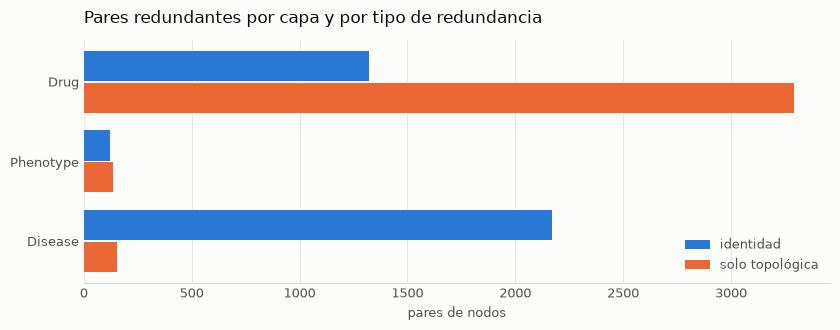

In [20]:
resumen = []
for resultado in [disease, phenotype, drug]:
    capa = resultado["capa"]
    tabla = resultado["tabla"]
    de_identidad = tabla[tabla["de_identidad"]]
    solo_topologica = tabla[tabla["vecindario"] & ~tabla["de_identidad"]]
    resumen.append({
        "capa": capa,
        "nodos": len(resultado["nodos"]),
        "pares de identidad": len(de_identidad),
        "nodos con duplicado": len({i for _, f in de_identidad.iterrows() for i in (f["id_a"], f["id_b"])}),
        "pares solo topológicos": len(solo_topologica),
        "cáscaras": len(resultado["cascaras"]),
    })
resumen = pd.DataFrame(resumen)
print(resumen.to_string(index=False))

figura, ax = plt.subplots(figsize=(8.5, 3.4), facecolor=SUPERFICIE)
ax.set_facecolor(SUPERFICIE)
posiciones = range(len(resumen))
ax.barh([p + 0.2 for p in posiciones], resumen["pares de identidad"], height=0.38,
        color=COLORES["identidad"], label="identidad")
ax.barh([p - 0.2 for p in posiciones], resumen["pares solo topológicos"], height=0.38,
        color=COLORES["topologica"], label="solo topológica")
ax.set_yticks(list(posiciones))
ax.set_yticklabels(resumen["capa"])
preparar(ax, "Pares redundantes por capa y por tipo de redundancia", "pares de nodos")
ax.legend(frameon=False, fontsize=9, labelcolor=TINTA_SUAVE)
plt.tight_layout()
plt.show()

## Con qué derecho se dice que dos nodos son el mismo

Conviene ser explícito: ninguna de las señales prueba identidad, son indicios de fuerza muy distinta
y hasta acá se estaban tratando como si valieran lo mismo. La capa `Drug` permite medirlo, porque
tiene una propiedad que sí es un criterio duro e independiente de toda ontología: el InChIKey, que
es un hash de la estructura molecular. Dos drogas que lo comparten son la misma sustancia, y eso no
se discute.

Usándolo como referencia sobre los pares donde los dos nodos lo traen, cada señal acierta esto:

| Señal | Pares verificables | Aciertos | Precisión |
|---|---:|---:|---:|
| `nombre` | 218 | 70 | **0,32** |
| `sinonimo` | 431 | 74 | **0,17** |
| `vecindario` | 1.492 | 0 | **0,00** |

Tres conclusiones, y ninguna era obvia antes de medirla.

**El nombre compartido acierta una de cada tres veces.** Es la señal más intuitiva y es mala sola.
La cobertura, en cambio, es alta: detecta 70 de los 75 pares que el InChIKey marca como la misma
molécula. Sirve para proponer candidatos, no para decidir.

**El sinónimo es peor todavía**, con 0,17. Ya se había visto cualitativamente en el grupo que juntaba
tumores distintos, y acá tiene número.

**El vecindario idéntico acierta cero veces de 1.492.** Es la confirmación cuantitativa de que mide
otra cosa: dos nodos indistinguibles en el grafo son, casi siempre, entidades diferentes.

Y lo que invalida contar señales: `sinonimo` y `referencia` se solapan en 809 de sus pares, así que
un par con esas dos no tiene dos evidencias independientes sino la misma dos veces. Medido sobre
`Drug`, exigir dos señales da una precisión de 0,04.

Lo que sí distingue es **qué** señal, no cuántas. Solo dos de las cuatro afirman una equivalencia en
vez de inferirla desde el texto: `referencia`, que son las referencias cruzadas que la propia
ontología publica, y `externo`, que es un identificador de un tercero como el InChIKey o el UMLS CUI.
Sobre los pocos pares de `Disease` que se pueden verificar contra el UMLS CUI, `referencia` acierta
13 de 13, aunque son pocos como para que el número signifique demasiado.

### Esto ya está reportado, y la solución no es una heurística

Antes de refinar más el criterio conviene mirar aguas arriba, porque el problema es conocido. El
issue [#204 del repositorio de OptimusKG](https://github.com/mims-harvard/optimuskg/issues/204),
titulado *deplicates with deprecated id*, reporta exactamente esto y sus autores lo respondieron:

> This is not a bug in how we build the graph and it comes from the OpenTargets version we're pinned
> to. We currently pin OT 25.06, and in that release EFO_0000274 is still the canonical id for atopic
> eczema. Meanwhile our MONDO snapshot is newer and already knows MONDO_0004980, so the two ids never
> meet and both end up as nodes.

El ejemplo que dan, `atopic eczema`, es uno de los pares que este notebook detecta. **La causa no es
que falte deduplicar sino un desfasaje de versiones**: el índice de enfermedades viene de una versión
de Open Targets donde el identificador canónico todavía es el de EFO, y la ontología MONDO viene de
un snapshot posterior que ya migró. Los dos nunca se cruzan porque el pipeline los carga por caminos
distintos.

Dicen además que la versión siguiente de Open Targets lo arregla en el origen, con el identificador
viejo listado en `obsoleteTerms` del nuevo, y que van a actualizar apenas termine la revisión del
paper. **Eso todavía no está en los datos que se usan acá**: se verifica abajo que la propiedad
`obsolete_terms` está presente pero nunca apunta a otro nodo de la capa.

La consecuencia práctica es que el criterio correcto no es una heurística propia sino el mapeo que
publica la ontología. MONDO existe justamente para eso y publica sus equivalencias en formato SSSOM,
con predicados explícitos que distinguen una coincidencia exacta de una más amplia o más estrecha.
Parte de esos mapeos ya están adentro del grafo, en la propiedad `xrefs`, que es de donde sale la
señal `referencia` de este notebook: son los 1.062 pares que apuntan a otro nodo de la capa.

In [21]:
#el caso del issue 204, y si el arreglo de aguas arriba ya llego a estos datos
print(consultar("""
    MATCH (n:Disease) WHERE n.id IN ['EFO_0000274', 'MONDO_0004980']
    RETURN n.id AS id, n.name AS nombre, COUNT { (n)--() } AS grado,
           size(coalesce(n.obsolete_terms, [])) AS obsolete_terms""").to_string(index=False))

#si obsolete_terms trajera el mapeo, el problema estaria resuelto en el dato y no haria falta inferir
for propiedad in ["obsolete_terms", "obsolete_xrefs", "xrefs"]:
    columna = nodos_disease[propiedad] if propiedad in nodos_disease else None
    referencias = consultar(f"""
        MATCH (n:Disease) WHERE n.is_truly_disease AND n.{propiedad} IS NOT NULL
        RETURN n.id AS id, n.{propiedad} AS valores""")
    pares = pares_por_referencia(dict(zip(referencias["id"], referencias["valores"])),
                                 list(nodos_disease["id"]))
    print(f"{propiedad:16s} apunta a otro nodo de la capa en {len(pares):5d} pares")

           id        nombre  grado  obsolete_terms
  EFO_0000274 atopic eczema   3215               0
MONDO_0004980 atopic eczema     12               0


obsolete_terms   apunta a otro nodo de la capa en     0 pares


obsolete_xrefs   apunta a otro nodo de la capa en     7 pares


xrefs            apunta a otro nodo de la capa en  1062 pares


## Las equivalencias declaradas

Con lo anterior, el criterio de identidad deja de ser una cuenta de señales y pasa a ser lo que la
ontología declara. Se construye en dos pasos, y el orden importa: primero con lo que ya está adentro
de la base, que no requiere nada externo, y después con el archivo de mapeos que publica MONDO, que
agrega lo que la base perdió al aplanar.

### Forma 3, primero: los `xrefs` que ya están en la base

Cada nodo MONDO trae en `xrefs` la lista de identificadores equivalentes en otros vocabularios, y
cuando uno de esos identificadores existe como nodo de la capa, el nodo está diciendo que el otro es
él mismo. Es la señal `referencia` de más arriba, ahora tomada como fuente y no como indicio. Las
referencias de `obsolete_xrefs` se cuentan pero **no entran**: son las que la propia ontología marcó
como deprecadas.

El límite de esta vía es doble. Solo 8.661 de los 17.308 nodos traen `xrefs`. Y al aplanar la lista
a strings, OptimusKG perdió el predicado: en el archivo original cada mapeo dice si es una
coincidencia exacta o un término más amplio, y acá no se puede distinguir.

In [22]:
ids_disease = list(nodos_disease["id"])
xrefs_por_nodo = {f["id"]: f["xrefs"] for f in nodos_disease.to_dict("records") if f["xrefs"] is not None}
obsoletos_por_nodo = {f["id"]: f["obsolete_xrefs"] for f in nodos_disease.to_dict("records")
                      if f["obsolete_xrefs"] is not None}

pares_xrefs = sorted({(a, b) for a, b, _ in pares_por_referencia(xrefs_por_nodo, ids_disease)})
pares_obsoletos = sorted({(a, b) for a, b, _ in pares_por_referencia(obsoletos_por_nodo, ids_disease)})
print(f"pares declarados por xrefs:          {len(pares_xrefs):5d}")
print(f"pares por obsolete_xrefs, excluidos: {len(pares_obsoletos):5d}")

pares declarados por xrefs:           1062
pares por obsolete_xrefs, excluidos:     7


### Forma 2, como complemento: el archivo SSSOM de MONDO

MONDO publica sus equivalencias como un archivo aparte en el estándar SSSOM del OBO Foundry: una
tabla con sujeto, predicado, objeto y justificación por fila. Sobre los `xrefs` agrega dos cosas: el
predicado explícito (`skos:exactMatch` contra `skos:broadMatch`, que no hay que fusionar) y la
trazabilidad de cada mapeo.

**El archivo se fija a un release y no al PURL.** La dirección canónica
`purl.obolibrary.org/obo/mondo/mappings/mondo.sssom.tsv` redirige a la rama `master` del
repositorio de MONDO, o sea que cambia en silencio cada vez que alguien hace un commit. Acá se baja
la versión del release `v2026-09-01` y se verifica su sha256 contra el registrado: si el archivo
que hay en disco no es exactamente ese, la celda corta, porque las cuentas de más abajo no serían
las que se documentan.

In [23]:
import hashlib
import urllib.request

MONDO_TAG = "v2026-09-01"
MONDO_SSSOM_URL = (f"https://raw.githubusercontent.com/monarch-initiative/mondo/{MONDO_TAG}"
                   "/src/ontology/mappings/mondo.sssom.tsv")
MONDO_SSSOM_SHA256 = "317ac4bf93be1deff4406b4d7d18bb730ead3c4f5c7c814f75d24be7f6ef302f"
ruta_sssom = Path("datos") / "mondo.sssom.tsv"

if not ruta_sssom.exists():
    ruta_sssom.parent.mkdir(exist_ok=True)
    urllib.request.urlretrieve(MONDO_SSSOM_URL, ruta_sssom)
    print(f"bajado {ruta_sssom} desde el release {MONDO_TAG}")

sha_en_disco = hashlib.sha256(ruta_sssom.read_bytes()).hexdigest()
assert sha_en_disco == MONDO_SSSOM_SHA256,     f"el archivo en disco no es el del release {MONDO_TAG}: sha256 {sha_en_disco[:16]}"

sssom = pd.read_csv(ruta_sssom, sep="\t", comment="#", dtype=str)
pares_sssom = pares_desde_sssom(sssom, ids_disease)
n_broad = int((sssom["predicate_id"] == "skos:broadMatch").sum())
print(f"mapeos en el archivo: {len(sssom):,}, de los cuales {n_broad} son broadMatch y se excluyen")
print(f"pares exactMatch con los dos extremos en la capa: {len(pares_sssom):,}")

mapeos en el archivo: 109,715, de los cuales 89 son broadMatch y se excluyen
pares exactMatch con los dos extremos en la capa: 1,342


In [24]:
declarados = unir_declarados({"xrefs": pares_xrefs, "sssom": pares_sssom})
declarados["nombre_a"] = declarados["id_a"].map(nombres_disease)
declarados["nombre_b"] = declarados["id_b"].map(nombres_disease)
grado_disease = dict(zip(nodos_disease["id"], nodos_disease["grado"]))
declarados["grado_a"] = declarados["id_a"].map(grado_disease)
declarados["grado_b"] = declarados["id_b"].map(grado_disease)

print("pares declarados por fuente:")
print(declarados["fuente"].value_counts().to_string())

#cuantos de los que solo ve el archivo tampoco los habia detectado ninguna heuristica
heuristicos = {(a, b) for a, b in zip(tabla_disease["id_a"], tabla_disease["id_b"])}
solo_sssom = declarados[declarados["fuente"] == "sssom"]
nuevos = solo_sssom[[(a, b) not in heuristicos for a, b in zip(solo_sssom.id_a, solo_sssom.id_b)]]
print(f"\nde los {len(solo_sssom)} que solo declara el archivo, {len(nuevos)} no los detectaba ninguna heuristica:")
print(nuevos[["id_a", "nombre_a", "grado_a", "id_b", "nombre_b", "grado_b"]].head(8).to_string(index=False))

pares declarados por fuente:
fuente
ambas    1015
sssom     327
xrefs      47

de los 327 que solo declara el archivo, 48 no los detectaba ninguna heuristica:
       id_a                          nombre_a  grado_a          id_b                                                 nombre_b  grado_b
EFO_0000272                       astrocytoma    10701 MONDO_0019781                     astrocytoma (excluding glioblastoma)        4
EFO_0000309                 Burkitts lymphoma     2252 MONDO_0007243                                         Burkitt lymphoma        1
EFO_0000464                         emphysema     1876 MONDO_0004849                                      pulmonary emphysema        3
EFO_0000677    mental or behavioural disorder    16649 MONDO_0005084                                          mental disorder        7
EFO_0000717              systemic scleroderma     3110 MONDO_0005100                                       systemic sclerosis        1
EFO_0001378                  mu

Los pares que solo declara el archivo son la evidencia de que los `xrefs` de la base están
incompletos, y los que ninguna heurística detectaba son duplicados que el resto de este notebook
estaba perdiendo. Al revés, los pares que solo declaran los `xrefs` son mapeos que el MONDO actual
ya no sostiene: el desfasaje de versiones del issue #204 visto desde el otro lado.

### Lo que ninguna de las dos declara

Las dos vías tienen el mismo punto ciego, y conviene dejarlo escrito antes de que alguien lo busque
en la tabla y no lo encuentre. **Los pares donde los dos nodos son MONDO no son detectables por
equivalencias declaradas.** El archivo SSSOM mapea términos de MONDO contra vocabularios externos,
nunca contra otros términos de MONDO, y los `xrefs` de un nodo MONDO tampoco apuntan a otro MONDO.
Se verifican las dos cosas y se listan los pares que las heurísticas sí marcan, para revisar a mano.
La fuente que los cubriría son los términos que MONDO deprecó y marcó con su reemplazo, que es otro
archivo del mismo release y no se usa acá.

In [25]:
mondo_a_mondo_en_sssom = int((sssom["subject_id"].str.startswith("MONDO")
                              & sssom["object_id"].str.startswith("MONDO")).sum())
mondo_a_mondo_en_xrefs = sum(1 for a, b in pares_xrefs if a.startswith("MONDO") and b.startswith("MONDO"))
print(f"filas MONDO a MONDO en el archivo SSSOM: {mondo_a_mondo_en_sssom}")
print(f"pares MONDO a MONDO declarados por xrefs: {mondo_a_mondo_en_xrefs}")

es_mondo = lambda i: str(i).startswith("MONDO")
declarados_set = {(a, b) for a, b in zip(declarados.id_a, declarados.id_b)}
no_declarables = tabla_disease[tabla_disease["de_identidad"]
                               & tabla_disease["id_a"].map(es_mondo) & tabla_disease["id_b"].map(es_mondo)]
no_declarables = no_declarables[[(a, b) not in declarados_set for a, b in zip(no_declarables.id_a, no_declarables.id_b)]]
#con lo medido sobre las señales sueltas (0,32 y 0,17 de precision), la mayoria de estos no seran
#duplicados reales: son candidatos sin fuente que los confirme, y por eso van a revision y no a la tabla
print(f"\npares MONDO + MONDO que marcan las heuristicas y ninguna fuente declara: {len(no_declarables)}, "
      f"de los cuales {(no_declarables['n_senales'] >= 2).sum()} con dos o mas señales")
print(no_declarables[["id_a", "nombre_a", "grado_a", "id_b", "nombre_b", "grado_b", "n_senales"]]
      .sort_values("grado_a", ascending=False).head(10).to_string(index=False))

filas MONDO a MONDO en el archivo SSSOM: 0
pares MONDO a MONDO declarados por xrefs: 0

pares MONDO + MONDO que marcan las heuristicas y ninguna fuente declara: 481, de los cuales 29 con dos o mas señales
         id_a                                          nombre_a  grado_a          id_b                                                 nombre_b  grado_b  n_senales
MONDO_0002025                              psychiatric disorder    17171 MONDO_0005084                                          mental disorder        7          1
MONDO_0008903                                       lung cancer    14213 MONDO_0021117                                            lung neoplasm    14285          2
MONDO_0002691                                      liver cancer    13533 MONDO_0018531        carcinoma of liver and intrahepatic biliary tract    13509          2
MONDO_0018531 carcinoma of liver and intrahepatic biliary tract    13509 MONDO_0044791 combined hepatocellular carcinoma and cholangiocarci

In [26]:
#cobertura: de los pares declarados, cuantos detectaba cada heuristica. es la validacion de las
#heuristicas en Disease, donde no habia un criterio duro como el InChIKey
print("de los pares declarados, cuantos detectaba cada heuristica:")
for senal in ["nombre", "sinonimo", "referencia", "externo", "vecindario"]:
    marcados = {(a, b) for a, b, v in zip(tabla_disease.id_a, tabla_disease.id_b, tabla_disease[senal]) if v}
    print(f"  {senal:12s} {len(marcados & declarados_set):5d} de {len(declarados_set)}")

#y al reves: lo que las heuristicas marcan y no esta declarado, por combinacion de ontologias
esp = lambda i: str(i).split("_")[0].split(":")[0]
sobrantes = tabla_disease[tabla_disease["de_identidad"]]
sobrantes = sobrantes[[(a, b) not in declarados_set for a, b in zip(sobrantes.id_a, sobrantes.id_b)]]
print(f"\npares de identidad por heuristicas que no estan declarados: {len(sobrantes)}")
print(pd.Series([" + ".join(sorted([esp(a), esp(b)])) for a, b in zip(sobrantes.id_a, sobrantes.id_b)])
      .value_counts().to_string())

de los pares declarados, cuantos detectaba cada heuristica:
  nombre         529 de 1389
  sinonimo       898 de 1389
  referencia    1062 de 1389
  externo         13 de 1389
  vecindario       0 de 1389

pares de identidad por heuristicas que no estan declarados: 830
MONDO + MONDO          481
EFO + MONDO            263
MONDO + Orphanet        73
EFO + Orphanet          10
EFO + EFO                2
Orphanet + Orphanet      1


In [27]:
grupos_declarados = grupos_de_equivalencia(list(declarados_set))
tamanos = pd.Series([len(g) for g in grupos_declarados])
print(f"{len(grupos_declarados)} grupos de equivalencia sobre {tamanos.sum()} nodos, "
      f"el mas grande de {tamanos.max()}, {(tamanos > 2).sum()} de mas de dos")

declarados.to_csv("pares_declarados_disease.csv", index=False)
print(f"{len(declarados)} pares escritos en pares_declarados_disease.csv")

1380 grupos de equivalencia sobre 2769 nodos, el mas grande de 3, 9 de mas de dos
1389 pares escritos en pares_declarados_disease.csv


## Un criterio para quedarse con un nodo por grupo

Nada de esto está aplicado y el notebook no escribe en Neo4j. Queda escrito acá porque la pregunta
de qué hacer aparece apenas se ve la tabla, y conviene que el criterio esté medido antes de
discutirlo.

La intuición razonable es quedarse con el nodo que tiene más aristas. Medida contra los datos,
funciona mejor de lo esperado: **resuelve casi todos los grupos por sí sola, y nunca elige mal**.
Se comprobó lo segundo comparando el ganador por grado total contra el ganador por grado contando
solo las relaciones que el algoritmo usa para cosechar semillas, que es lo que de verdad importa: no
hubo un solo grupo donde difirieran. O sea que no existe el caso que haría fallar al criterio, un
nodo inflado por aristas irrelevantes que le gane a otro con menos aristas pero mejores.

Para el 1,6% que empata hace falta seguir, y la cascada completa queda así.

| Nivel | Criterio | Por qué |
|---|---|---|
| 1 | Más aristas | Es el nodo sobre el que la fuente principal acumuló la evidencia |
| 2 | Más aristas de jerarquía `PARENT` | Es el patrón exacto de los empates: un nodo MONDO ubicado en la taxonomía contra un Orphanet suelto |
| 3 | Prioridad de ontología, MONDO primero | MONDO existe para ser el identificador único de una enfermedad, es la que armoniza a las demás |
| 4 | Identificador menor | No es un criterio sustantivo: está para que el resultado no dependa del orden en que llegue el grupo |

Cuántos grupos resuelve cada nivel se calcula en la celda de abajo. El nivel 4 no debería usarse
nunca sobre estos datos y conviene dejarlo igual, porque sin él dos corridas podrían elegir
representantes distintos para el mismo grupo.

Dos decisiones previas que el criterio no toma por su cuenta.

**Con qué pares se arman los grupos.** Con los declarados de la sección anterior, agrupados por
componentes conexas: si A es igual a B y B es igual a C, los tres caen en el mismo grupo. Vale
registrar por qué no con las heurísticas: usando todos sus pares aparece un grupo de 14 nodos que
junta `astrocytoma`, `ependymoma`, `subependymoma` y `adult glioblastoma`, que son tumores distintos,
y pedir que dos señales respalden cada par tampoco alcanza, porque no son independientes entre sí.

**Qué pasa con las aristas del nodo que no es representante.** Acá está el costo real del criterio,
y es lo que hay que decidir con los ojos abiertos: quedarse solo con el representante **descarta
21.708 aristas**, el 4,8% de las que tienen esos nodos entre todos. No están repartidas parejo. En
298 pares los dos vecindarios son completamente disjuntos, de modo que ahí no se pierde una fracción
sino todo lo que tenía el otro nodo.

La alternativa, que no requiere elegir distinto sino arrastrar en vez de descartar, es usar el
representante como destino y unir las aristas de todo el grupo. El criterio de selección es el mismo
en los dos casos.

In [28]:
#el criterio, corrido para reportar: no se escribe nada en Neo4j y no se filtra ningun nodo.
#los grupos son los de las equivalencias declaradas
involucrados = sorted({i for grupo in grupos_declarados for i in grupo})
perfil = consultar("""
    MATCH (n:Disease) WHERE n.id IN $ids
    RETURN n.id AS id, n.name AS nombre, COUNT { (n)--() } AS grado,
           COUNT { (n)-[:PARENT]-() } AS jerarquia""", ids=involucrados)
grado = dict(zip(perfil["id"], perfil["grado"]))
jerarquia = dict(zip(perfil["id"], perfil["jerarquia"]))
nombre_de = dict(zip(perfil["id"], perfil["nombre"]))

#en que nivel de la cascada se decide cada grupo, reproduciendo los criterios de elegir_representante
#uno por uno para poder contarlos
from redundancia import PRIORIDAD_DE_ONTOLOGIA
def nivel_que_decide(grupo):
    candidatos = [i for i in grupo if grado.get(i, 0) == max(grado.get(j, 0) for j in grupo)]
    if len(candidatos) == 1: return 1
    candidatos = [i for i in candidatos if jerarquia.get(i, 0) == max(jerarquia.get(j, 0) for j in candidatos)]
    if len(candidatos) == 1: return 2
    prioridad = lambda i: PRIORIDAD_DE_ONTOLOGIA.get(i.split("_")[0], len(PRIORIDAD_DE_ONTOLOGIA))
    candidatos = [i for i in candidatos if prioridad(i) == min(prioridad(j) for j in candidatos)]
    return 3 if len(candidatos) == 1 else 4

niveles = pd.Series([nivel_que_decide(g) for g in grupos_declarados]).value_counts().sort_index()
print("grupos decididos en cada nivel de la cascada:")
for nivel, etiqueta in [(1, "1. mas aristas"), (2, "2. mas jerarquia"), (3, "3. ontologia"), (4, "4. identificador")]:
    n = int(niveles.get(nivel, 0))
    print(f"  {etiqueta:20s} {n:5d}  ({100 * n / len(grupos_declarados):.1f}%)")

representantes = pd.DataFrame([
    {"representante": elegir_representante(grupo, grado, jerarquia),
     "nombre": nombre_de[elegir_representante(grupo, grado, jerarquia)],
     "tamaño_grupo": len(grupo),
     "grado_representante": grado[elegir_representante(grupo, grado, jerarquia)],
     "otros": ", ".join(i for i in grupo if i != elegir_representante(grupo, grado, jerarquia))}
    for grupo in grupos_declarados])
print(f"\n{len(grupos_declarados)} grupos sobre {len(involucrados)} nodos: quedarian {len(representantes)} "
      f"representantes y {len(involucrados) - len(representantes)} absorbidos, "
      f"{(representantes['tamaño_grupo'] > 2).sum()} grupos de mas de dos para revisar a mano")
representantes.sort_values("tamaño_grupo", ascending=False).head(8)

grupos decididos en cada nivel de la cascada:
  1. mas aristas        1361  (98.6%)
  2. mas jerarquia        19  (1.4%)
  3. ontologia             0  (0.0%)
  4. identificador         0  (0.0%)

1380 grupos sobre 2769 nodos: quedarian 1380 representantes y 1389 absorbidos, 9 grupos de mas de dos para revisar a mano


,representante,nombre,tamaño_grupo,grado_representante,otros
840,MONDO_0011669,hypotonia-cystinuria syndrome,3,894,"Orphanet_163690, Orphanet_238517"
196,MONDO_0000447,autosomal dominant polycystic liver disease,3,191,"MONDO_0008265, Orphanet_2924"
704,Orphanet_113,Bazex-Dupré-Christol syndrome,3,76,"MONDO_0010535, Orphanet_166113"
610,Orphanet_540,Familial hemophagocytic lymphohistiocytosis,3,858,"MONDO_0009974, MONDO_0015541"
647,MONDO_0015722,congenital vitamin K-dependent coagulation fac...,3,186,"MONDO_0010187, Orphanet_98434"
1032,MONDO_0013357,"chromosome 17q11.2 deletion syndrome, 1.4Mb",3,48,"Orphanet_137634, Orphanet_97685"
784,Orphanet_98909,Desminopathy,3,184,"MONDO_0011076, Orphanet_363543"
394,MONDO_0008572,"tibia, hypoplasia or aplasia of, with polydactyly",3,224,"Orphanet_3332, Orphanet_988"


In [29]:
#un nodo por fila, con su representante, para revisar el resultado del criterio. el script de
#marcado (marcar_id_canonico.py) no lee esta tabla: recalcula los mismos pares declarados por su
#cuenta, asi que se puede correr sin haber abierto este notebook. el representante se mapea a si
#mismo para que el mapeo sea una funcion total sobre los nodos del grupo
fuente_por_nodo = {}
for a, b, fuente in zip(declarados.id_a, declarados.id_b, declarados.fuente):
    for nodo in (a, b):
        fuente_por_nodo.setdefault(nodo, set()).add(fuente)

equivalencias = pd.DataFrame([
    {"id": nodo, "representante": elegir_representante(grupo, grado, jerarquia), "grupo": numero,
     "tamaño_grupo": len(grupo),
     "fuente": "ambas" if len(fuente_por_nodo[nodo]) > 1 or "ambas" in fuente_por_nodo[nodo]
               else next(iter(fuente_por_nodo[nodo]))}
    for numero, grupo in enumerate(grupos_declarados) for nodo in grupo]).sort_values(["grupo", "id"])
equivalencias.to_csv("equivalencias_disease.csv", index=False)

import datetime
trazabilidad = {
    "mondo_release": MONDO_TAG, "mondo_sssom_url": MONDO_SSSOM_URL, "mondo_sssom_sha256": MONDO_SSSOM_SHA256,
    "fecha": datetime.date.today().isoformat(),
    "pares_xrefs": len(pares_xrefs), "pares_sssom": len(pares_sssom),
    "pares_por_fuente": {k: int(v) for k, v in declarados["fuente"].value_counts().items()},
    "solo_sssom_sin_heuristica": len(nuevos), "broadmatch_excluidos": n_broad,
    "mondo_a_mondo_no_declarables": len(no_declarables),
    "grupos": len(grupos_declarados), "nodos": len(involucrados),
    "representantes": len(representantes), "absorbidos": len(involucrados) - len(representantes),
}
Path("equivalencias_disease.json").write_text(json.dumps(trazabilidad, indent=2, ensure_ascii=False))
print(f"{len(equivalencias)} filas en equivalencias_disease.csv, trazabilidad en equivalencias_disease.json")
equivalencias.head(6)

2769 filas en equivalencias_disease.csv, trazabilidad en equivalencias_disease.json


,id,representante,grupo,tamaño_grupo,fuente
0,EFO_0000182,EFO_0000182,0,2,sssom
1,MONDO_0007256,EFO_0000182,0,2,sssom
2,EFO_0000183,EFO_0000183,1,2,sssom
3,MONDO_0004952,EFO_0000183,1,2,sssom
4,EFO_0000222,EFO_0000222,2,2,sssom
5,MONDO_0018874,EFO_0000222,2,2,sssom


Tres cosas que este criterio no cubre y que conviene tener anotadas antes de aplicarlo alguna vez.

Los grupos de más de dos nodos son pocos y hay que mirarlos de a uno. Con las heurísticas había
aparecido uno que juntaba `mitochondrial DNA depletion syndrome 8a` con el `8b`, entidades distintas;
con las equivalencias declaradas ese tipo de error ya no debería entrar, pero la revisión a mano
sigue siendo la única forma de confirmarlo.

Los nueve pares que cruzan la frontera de `is_truly_disease` quedan afuera de esta tabla, porque la
tabla se construyó sobre los nodos que el filtro conserva. Son justamente los casos donde el
representante correcto está del lado descartado, así que si alguna vez se aplica un canónico habría
que resolverlos antes, o el criterio va a elegir bien entre los nodos equivocados.

Y la redundancia topológica no se arregla con esto. Un par con vecindario idéntico son dos entidades
distintas, así que no hay representante que elegir: lo que se puede hacer es decidir qué hace el
algoritmo cuando dos candidatos empatan.

Lo que queda para decidir, que este notebook no resuelve.

El criterio de qué hacer con un par. Marcar uno de los dos como canónico con una propiedad, al
estilo de `is_truly_disease`, es lo más barato y lo más reversible, pero deja las aristas repartidas
entre los dos nodos. Fusionarlos resuelve eso a costa de una escritura que no se deshace fácil.

Qué pasa con la evidencia del nodo secundario. Esto resultó ser lo más incómodo de lo que se midió:
los nodos secundarios no son cáscaras vacías. Entre los que ni siquiera participan de la jerarquía
hay decenas de miles de aristas hacia genes y fenotipos, o sea evidencia que el nodo principal no
tiene. Descartar el duplicado sin más pierde esa evidencia, y quedarse con los dos deja el conjunto
semilla partido en dos mitades que no se conectan entre sí.

Si la redundancia topológica se trata o se documenta. Un par con vecindario idéntico no se arregla
marcando un canónico, porque son entidades distintas. Lo que se puede hacer es reportar cuántos
empates de DIAMOnD vienen de ahí, y decidir si el criterio de desempate del algoritmo tiene que
dejar de depender del orden de recorrido.

## Verificación

Los valores de control son los que se midieron a mano contra la base al detectar el problema, antes
de que existiera este notebook. Sirven para que una normalización que se rompa en silencio haga
fallar la corrida en vez de devolver menos pares sin avisar.

Uno de esos valores estaba mal y el control lo encontró. El sondeo original contaba los nombres
repetidos con `toLower(trim(name))` en Cypher y daba 169 grupos, mientras que en Python dan 170. La
diferencia es `Orphanet_309827`, cuyo nombre termina en un espacio no separable: `trim()` no lo saca
y `strip()` sí. **Es la razón concreta de que toda la normalización viva en Python y no en la
consulta**, y sirve de advertencia para cualquier agrupamiento por nombre que se haga más adelante
directamente contra la base.

In [30]:
#el testigo tiene que estar entre los pares de identidad de Disease
par_testigo = tabla_disease[(tabla_disease["id_a"] == "EFO_0000182") &
                            (tabla_disease["id_b"] == "MONDO_0007256")]
assert len(par_testigo) == 1 and par_testigo.iloc[0]["de_identidad"], "se perdio el par testigo"

#el sondeo a mano habia dado 169 grupos con toLower(trim(name)) en Cypher, y en Python dan 170. la
#diferencia es Orphanet_309827, cuyo nombre termina en un espacio no separable que trim() no saca y
#strip() si: el valor original subestimaba. es la razon de que la normalizacion viva en Python
minima = grupos_por_clave(nodos_disease, "nombre", normalizador=lambda n: (n or "").strip().lower())
assert len(minima) == 170, f"grupos con normalizacion minima en Disease: {len(minima)}, se esperaban 170"
assert len(disease["grupos_nombre"]) >= len(minima), "la normalizacion fuerte encontro menos grupos que la minima"

assert len(phenotype["senales"]["nombre"]) == 98, "pares por nombre en Phenotype"
assert sum(1 for _, _, d in drug["senales"]["externo"] if len(str(d)) == 27) == 75,     "pares por InChIKey en Drug"

#ningun par puede aparecer espejado en los CSV
for capa, resultado in [("Disease", disease), ("Phenotype", phenotype), ("Drug", drug)]:
    pares = {(f["id_a"], f["id_b"]) for _, f in resultado["tabla"].iterrows()}
    assert not {(b, a) for a, b in pares} & pares, f"hay pares espejados en {capa}"
    assert all(a < b for a, b in pares), f"hay pares sin ordenar en {capa}"

#las equivalencias declaradas, contra lo medido a mano el 2026-09-05 sobre el release v2026-09-01
assert len(pares_sssom) == 1342, f"pares SSSOM con los dos extremos en la capa: {len(pares_sssom)}"
assert mondo_a_mondo_en_sssom == 0, "el archivo SSSOM no deberia tener filas MONDO a MONDO"
assert n_broad == 89, f"broadMatch en el archivo: {n_broad}"
assert ("EFO_0000274", "MONDO_0004980") in declarados_set, "falta el par testigo del issue 204"

#el mapeo id a representante es una funcion total sobre los nodos del grupo
assert equivalencias["id"].is_unique, "un nodo aparece en mas de un grupo"
representantes_set = set(equivalencias["representante"])
assert representantes_set <= set(equivalencias["id"]), "hay un representante que no esta mapeado a si mismo"
assert all(equivalencias[equivalencias["id"] == r]["representante"].iloc[0] == r for r in representantes_set)
assert set(equivalencias["id"]) <= set(ids_disease), "hay un id fuera de las enfermedades reales"

print("los controles pasan: cinco de las heuristicas y seis de las equivalencias declaradas")

los controles pasan: cinco de las heuristicas y seis de las equivalencias declaradas


In [31]:
driver.close()